# Applied Machine Learning (Assignment # 2)

##### Submitted by
###### Amash Rizwan
###### 21F-9116
###### BCS-8B

#### Importing all the libraries

In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from scipy.stats import zscore
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


#### Part 1: Exploratory Data Analysis

In [2]:
# Loading the dataset
Dataset = pd.read_csv("MoMTSim_20240722202413_1000_dataset.csv")

print('Shape of Dataset', Dataset.shape)
print('Columns of Dataset', Dataset.columns)
Dataset.head(5)

Shape of Dataset (4225958, 10)
Columns of Dataset Index(['step', 'transactionType', 'amount', 'initiator', 'oldBalInitiator',
       'newBalInitiator', 'recipient', 'oldBalRecipient', 'newBalRecipient',
       'isFraud'],
      dtype='object')


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,PAYMENT,579.16,4018807983755588,29.32,29.32,30-0000345,0.00,0.00,0
1,0,TRANSFER,39.03,4610593854752035,39.03,0.00,4944921135715488,55.94,94.98,1
2,0,TRANSFER,21.78,4840578447365454,21.78,0.00,4305579785620656,58.09,79.88,1
3,0,PAYMENT,570.22,4958066799829630,5.29,5.29,00-0000388,0.00,0.00,0
4,0,PAYMENT,574.80,4149196095918843,82.63,82.63,80-0005320,0.00,0.00,0


In [3]:
missing_values = Dataset.isna().sum()
print("Number of missing values per column: \n", missing_values)

Number of missing values per column: 
 step               0
transactionType    0
amount             0
initiator          0
oldBalInitiator    0
newBalInitiator    0
recipient          0
oldBalRecipient    0
newBalRecipient    0
isFraud            0
dtype: int64


C:\Users\AMASH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


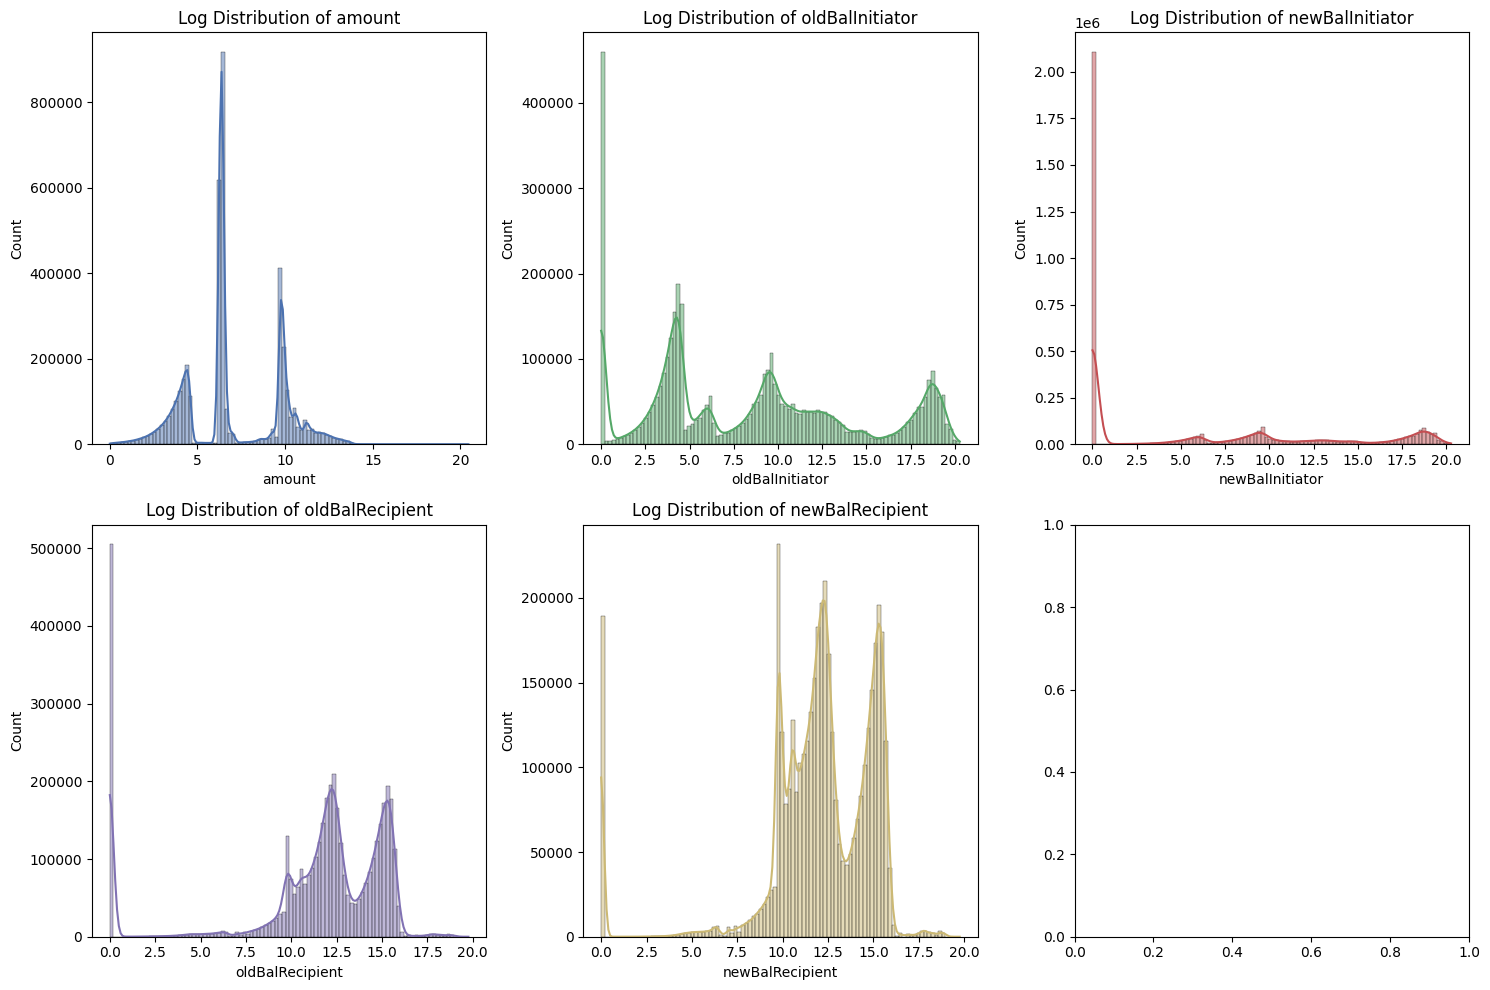

C:\Users\AMASH\AppData\Local\Temp\ipykernel_19056\2107891716.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=Dataset['isFraud'], palette=['#4C72B0', '#C44E52'])


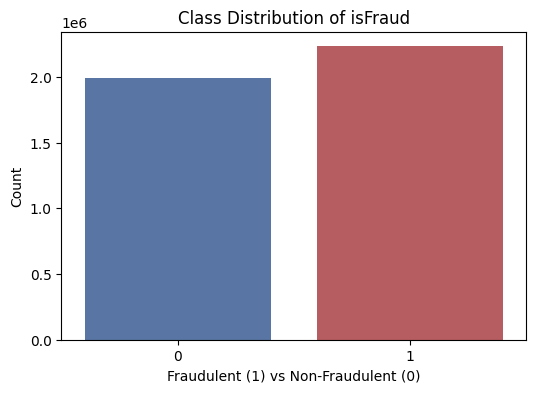

In [4]:
# Create a copy to preserve original data
Dataset_transformed = Dataset.copy()

# Applying log transformation to handle skewness
for col in ['amount', 'oldBalInitiator', 'newBalInitiator', 'oldBalRecipient', 'newBalRecipient']:
    Dataset_transformed[col] = np.log1p(Dataset_transformed[col])

# Plotting the histograms again with updated colors
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  
axes = axes.flatten()

cols = ['amount', 'oldBalInitiator', 'newBalInitiator', 'oldBalRecipient', 'newBalRecipient']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974'] 

for i, col in enumerate(cols):
    sns.histplot(Dataset_transformed[col], bins=100, kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f"Log Distribution of {col}")

# Hide the unused subplot (6th subplot)
#fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Checking class distribution of target variable 
plt.figure(figsize=(6, 4))
sns.countplot(x=Dataset['isFraud'], palette=['#4C72B0', '#C44E52'])
plt.title('Class Distribution of isFraud')
plt.xlabel('Fraudulent (1) vs Non-Fraudulent (0)')
plt.ylabel('Count')
plt.show()

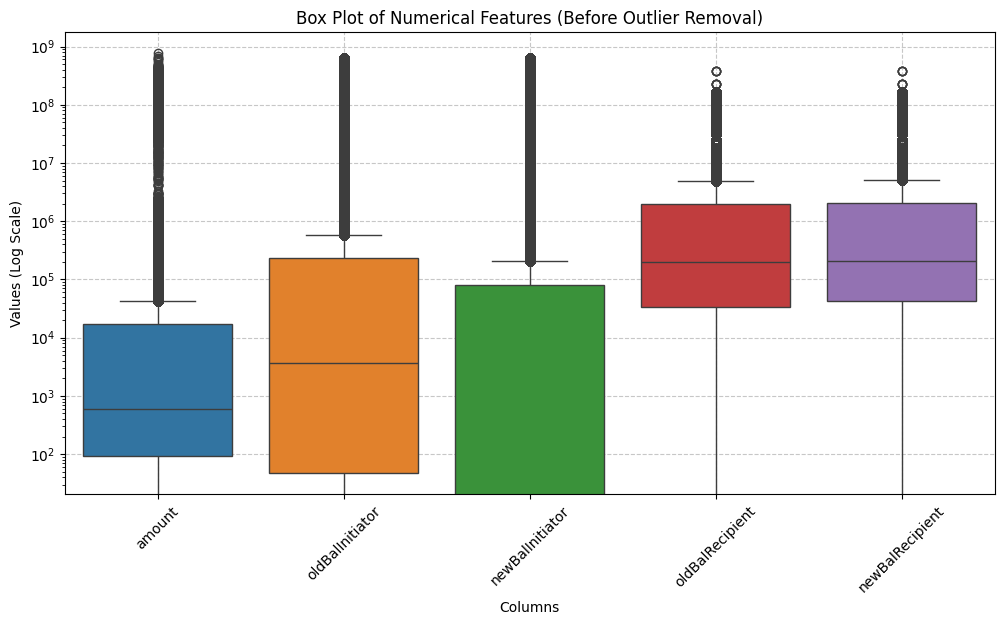

Original Dataset Shape: (4225958, 10)
Dataset Shape After Outlier Removal: (2622522, 10)


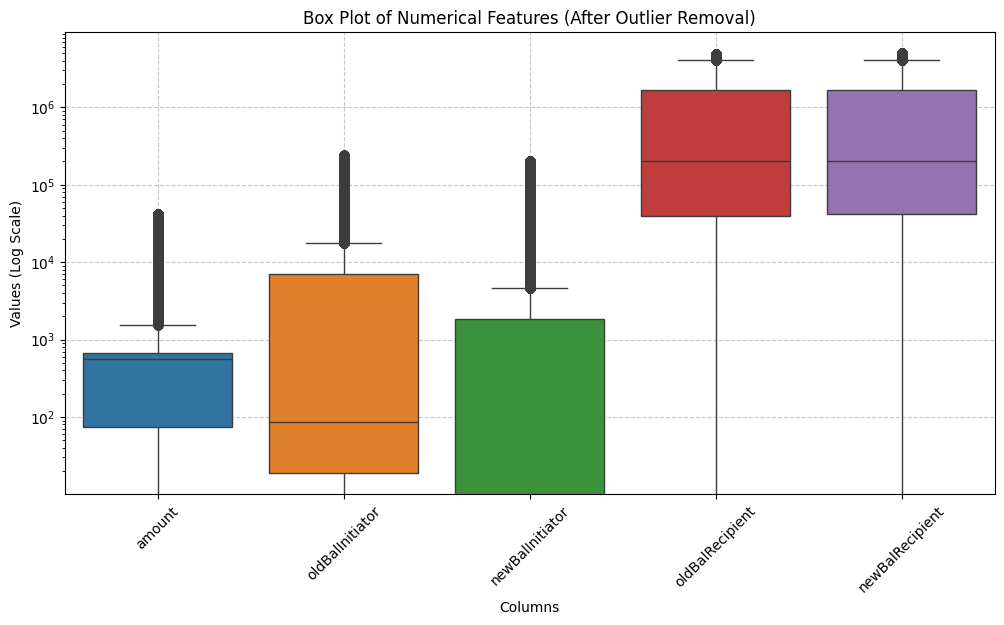

In [5]:
# Selecting only numerical columns, excluding 'step', 'initiator', and 'isFraud'
num_cols = Dataset.select_dtypes(include=['number']).columns
num_cols = num_cols.drop(['step', 'initiator', 'isFraud'], errors='ignore') 

# Boxplot Before Outlier Removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=Dataset[num_cols], showfliers=True)  # Shows Outliers
plt.yscale("log") # Better Visualization
plt.title("Box Plot of Numerical Features (Before Outlier Removal)")
plt.xlabel("Columns")
plt.ylabel("Values (Log Scale)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Removing Outliers Using IQR
def remove_outliers(df, cols):
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (df[cols] >= lower_bound) & (df[cols] <= upper_bound)
    df_cleaned = df[mask.all(axis=1)]  # Keep only rows without outliers

    return df_cleaned

Dataset_cleaned = remove_outliers(Dataset, num_cols)

# Dataset Comparison
print(f"Original Dataset Shape: {Dataset.shape}")
print(f"Dataset Shape After Outlier Removal: {Dataset_cleaned.shape}")

# Boxplot After Outlier Removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=Dataset_cleaned[num_cols], showfliers=True)  # Remaining Data Distribution
plt.yscale("log")
plt.title("Box Plot of Numerical Features (After Outlier Removal)")
plt.xlabel("Columns")
plt.ylabel("Values (Log Scale)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [6]:
def remove_outliers_zscore(df, cols, threshold=3):
    z_scores = df[cols].apply(zscore)
    mask = (z_scores.abs() < threshold).all(axis=1)
    return df[mask]

Dataset_cleaned_z = remove_outliers_zscore(Dataset, num_cols)

# Comparison of dataset sizes
print(f"Dataset Shape After IQR Outlier Removal: {Dataset_cleaned.shape}")
print(f"Dataset Shape After Z-score Outlier Removal: {Dataset_cleaned_z.shape}")

Dataset Shape After IQR Outlier Removal: (2622522, 10)
Dataset Shape After Z-score Outlier Removal: (4069204, 10)


In [7]:
summary_stats = Dataset_cleaned.describe()
print("Summary Statistics (After IQR Outlier Removal):\n", summary_stats)

Summary Statistics (After IQR Outlier Removal):
                step        amount     initiator  oldBalInitiator  \
count  2.622522e+06  2.622522e+06  2.622522e+06     2.622522e+06   
mean   8.566435e+01  4.534729e+03  4.493923e+15     8.671385e+03   
std    5.352295e+01  9.069113e+03  2.895260e+14     2.664793e+04   
min    0.000000e+00  0.000000e+00  4.000000e+15    -1.499333e+05   
25%    3.900000e+01  7.326000e+01  4.246217e+15     1.871000e+01   
50%    8.300000e+01  5.633500e+02  4.488559e+15     8.703000e+01   
75%    1.290000e+02  6.682300e+02  4.742545e+15     7.006680e+03   
max    1.920000e+02  4.256988e+04  5.000000e+15     2.446710e+05   

       newBalInitiator  oldBalRecipient  newBalRecipient       isFraud  
count     2.622522e+06     2.622522e+06     2.622522e+06  2.622522e+06  
mean      6.622606e+03     9.951725e+05     9.972226e+05  5.552186e-01  
std       2.449895e+04     1.420627e+06     1.421242e+06  4.969416e-01  
min      -1.222279e+05     0.000000e+00     0.

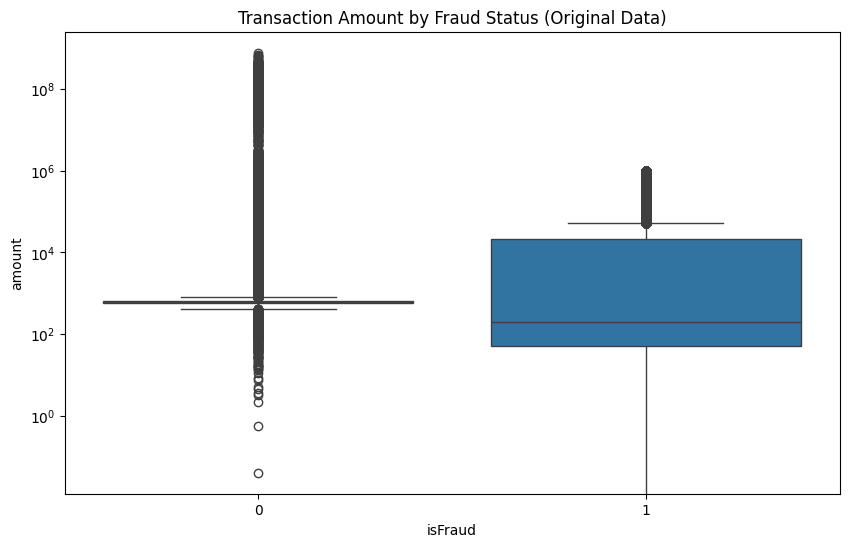

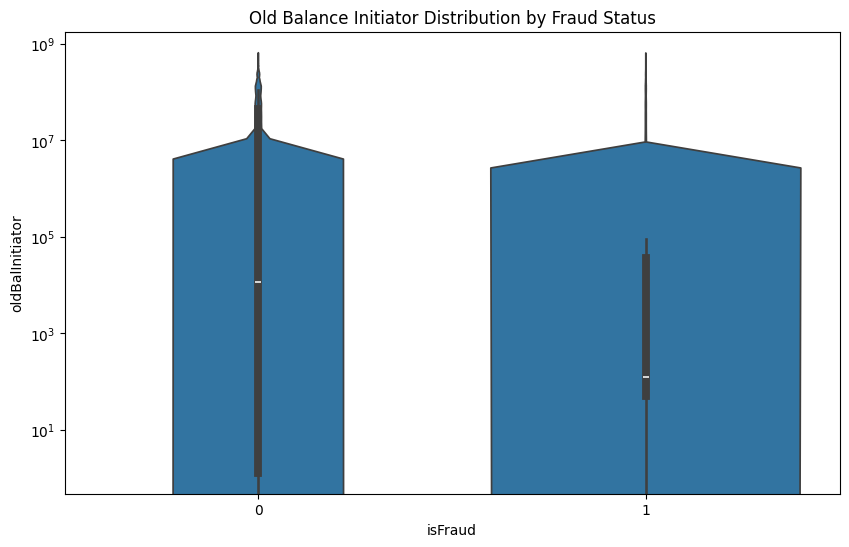

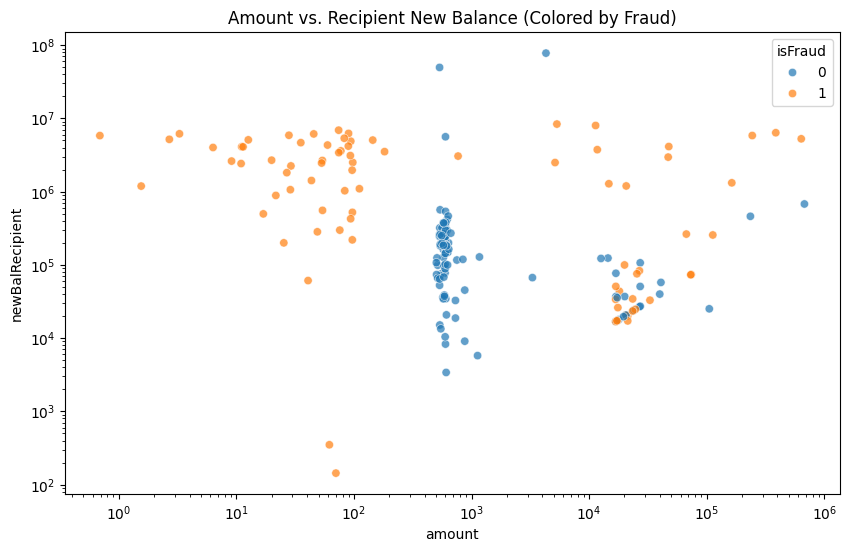

In [8]:
# Boxplot of 'amount' vs 'isFraud' (to show outliers per class)
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=Dataset)
plt.title('Transaction Amount by Fraud Status (Original Data)')
plt.yscale('log')  # Log scale for better visualization
plt.show()

# Violin plot for balance features
plt.figure(figsize=(10, 6))
sns.violinplot(x='isFraud', y='oldBalInitiator', data=Dataset)
plt.title('Old Balance Initiator Distribution by Fraud Status')
plt.yscale('log')
plt.show()

# Scatter plot (sampled for clarity)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='amount', y='newBalRecipient', hue='isFraud', 
                data=Dataset.sample(200), alpha=0.7)
plt.title('Amount vs. Recipient New Balance (Colored by Fraud)')
plt.yscale('log')
plt.xscale('log')
plt.show()

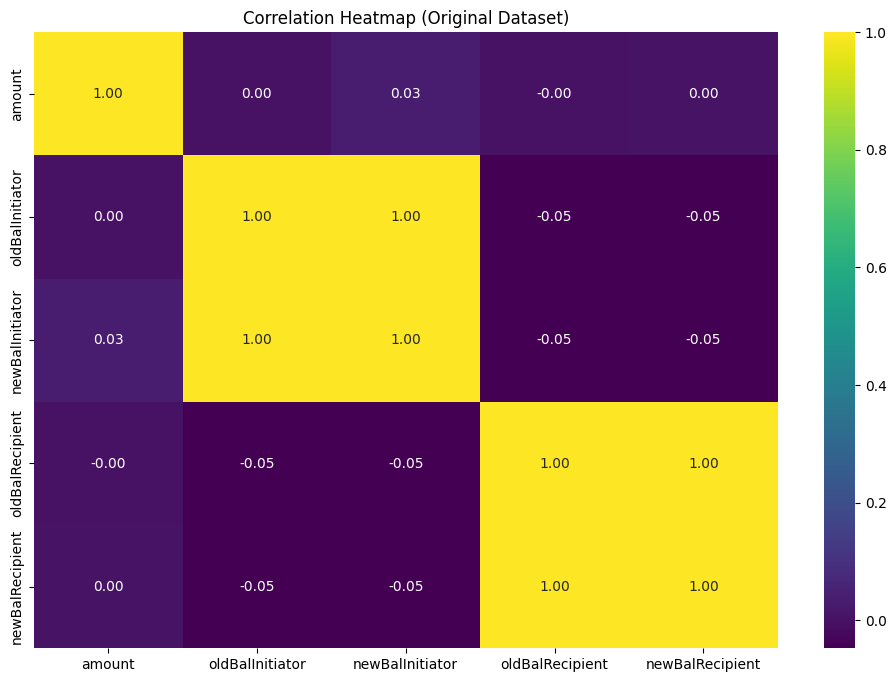

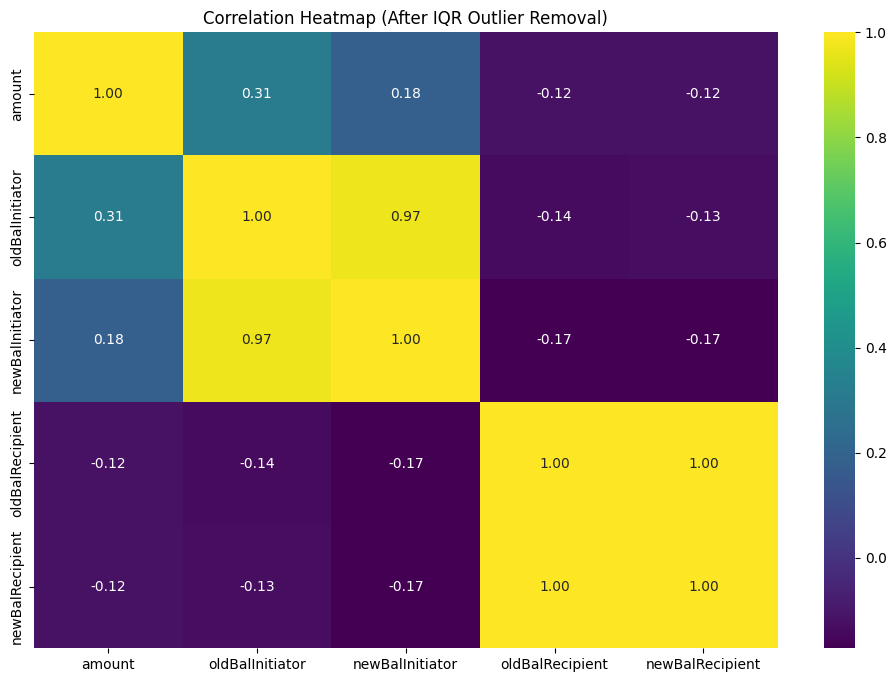

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(Dataset[num_cols].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap (Original Dataset)")
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(Dataset_cleaned[num_cols].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap (After IQR Outlier Removal)")
plt.show()

C:\Users\AMASH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


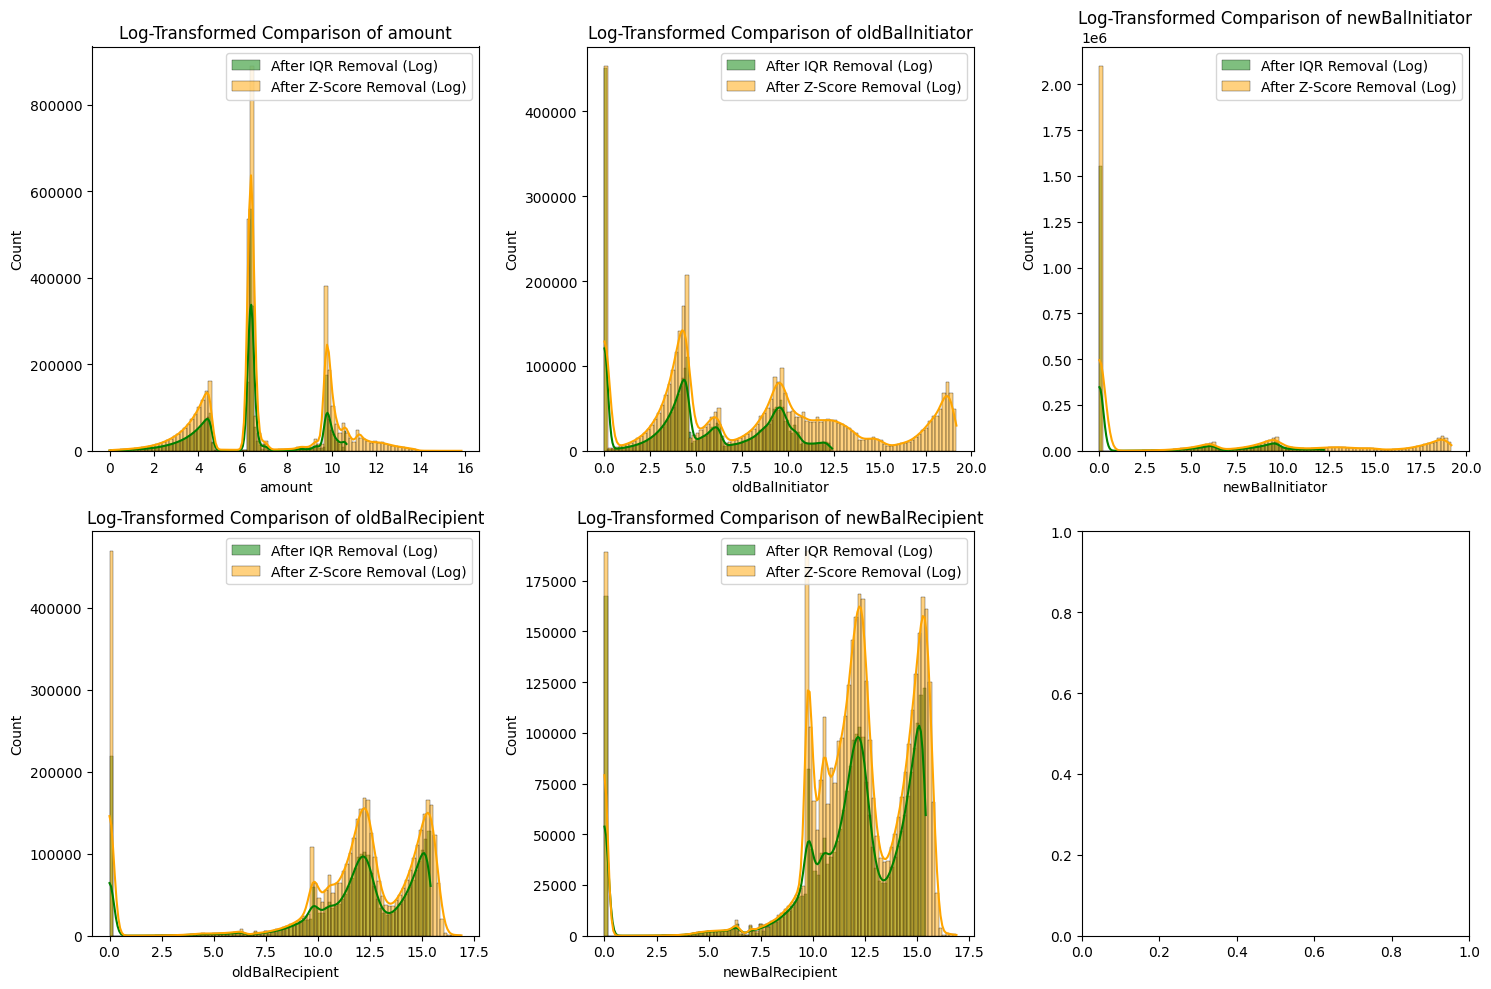


Original Dataset Statistics:
            amount  oldBalInitiator  newBalInitiator  oldBalRecipient  \
mean  5.302139e+04     2.246055e+07     2.246527e+07     1.685005e+06   
50%   5.966900e+02     3.655435e+03     0.000000e+00     2.007614e+05   
std   2.708194e+06     6.418504e+07     6.421561e+07     6.795783e+06   
min   0.000000e+00    -1.999926e+05    -1.999926e+05    -7.477966e+04   
max   7.654805e+08     6.409231e+08     6.409231e+08     3.810134e+08   

      newBalRecipient  
mean     1.703967e+06  
50%      2.042479e+05  
std      6.802160e+06  
min      0.000000e+00  
max      3.813883e+08  

Cleaned Dataset (IQR) Statistics:
            amount  oldBalInitiator  newBalInitiator  oldBalRecipient  \
mean   4534.728505      8671.385264      6622.605857     9.951725e+05   
50%     563.350000        87.030000         0.000000     2.029481e+05   
std    9069.112745     26647.933843     24498.947284     1.420627e+06   
min       0.000000   -149933.310000   -122227.880000     0.0

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Defining columns for transformation
cols = ['amount', 'oldBalInitiator', 'newBalInitiator', 'oldBalRecipient', 'newBalRecipient']

# Making copies of datasets
Dataset_cleaned_log = Dataset_cleaned.copy()
Dataset_cleaned_z_log = Dataset_cleaned_z.copy()

# Applying log transformation (log1p handles zero values)
for col in cols:
    Dataset_cleaned_log[col] = np.log1p(Dataset_cleaned_log[col])
    Dataset_cleaned_z_log[col] = np.log1p(Dataset_cleaned_z_log[col])

# Plotting histograms for log-transformed data
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(Dataset_cleaned_log[col], bins=100, kde=True, ax=axes[i], color="green", label="After IQR Removal (Log)")
    sns.histplot(Dataset_cleaned_z_log[col], bins=100, kde=True, ax=axes[i], color="orange", alpha=0.5, label="After Z-Score Removal (Log)")
    axes[i].set_title(f"Log-Transformed Comparison of {col}")
    axes[i].legend()

plt.tight_layout()
plt.show()

# Comparing original vs cleaned data statistics
print("\nOriginal Dataset Statistics:")
print(Dataset[num_cols].describe().loc[['mean', '50%', 'std', 'min', 'max']])

print("\nCleaned Dataset (IQR) Statistics:")
print(Dataset_cleaned[num_cols].describe().loc[['mean', '50%', 'std', 'min', 'max']])

# Key metrics comparison
stats_comparison = pd.DataFrame({
    'Original Mean': Dataset[num_cols].mean(),
    'Cleaned Mean (IQR)': Dataset_cleaned[num_cols].mean(),
    'Difference (%)': (Dataset[num_cols].mean() - Dataset_cleaned[num_cols].mean()) / Dataset[num_cols].mean() * 100
})
print("\nMean Value Comparison (Original vs. Cleaned):")
print(stats_comparison)

#### Part 2: Data Preprocessing and Dataset Splitting

In [11]:
df_clean = Dataset_cleaned.copy()
missing_values = df_clean.isna().sum()
print("Number of missing values per column: \n", missing_values)

Number of missing values per column: 
 step               0
transactionType    0
amount             0
initiator          0
oldBalInitiator    0
newBalInitiator    0
recipient          0
oldBalRecipient    0
newBalRecipient    0
isFraud            0
dtype: int64


In [12]:
# One-hot encoding
print("Unique transaction types:", df_clean['transactionType'].unique())
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_types = encoder.fit_transform(df_clean[['transactionType']])
encoded_df = pd.DataFrame(encoded_types, columns=encoder.get_feature_names_out(['transactionType']))

# Ensure index alignment
df_temp = df_clean.drop('transactionType', axis=1).reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

# Concatenate
df_processed = pd.concat([df_temp, encoded_df], axis=1)
print(df_processed.head(5))

# Verify no NaN
missing_values = df_processed.isna().sum()
print("Missing values after fix:\n", missing_values)

# All should be showing zeros

Unique transaction types: ['PAYMENT' 'TRANSFER' 'DEBIT' 'DEPOSIT' 'WITHDRAWAL']
   step  amount         initiator  oldBalInitiator  newBalInitiator  \
0     0  579.16  4018807983755588            29.32            29.32   
1     0   39.03  4610593854752035            39.03             0.00   
2     0   21.78  4840578447365454            21.78             0.00   
3     0  570.22  4958066799829630             5.29             5.29   
4     0  574.80  4149196095918843            82.63            82.63   

          recipient  oldBalRecipient  newBalRecipient  isFraud  \
0        30-0000345             0.00             0.00        0   
1  4944921135715488            55.94            94.98        1   
2  4305579785620656            58.09            79.88        1   
3        00-0000388             0.00             0.00        0   
4        80-0005320             0.00             0.00        0   

   transactionType_DEPOSIT  transactionType_PAYMENT  transactionType_TRANSFER  \
0              

In [13]:
# Split data (stratified by fraud class)
X = df_processed.drop('isFraud', axis=1)
y = df_processed['isFraud']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    stratify=y, 
    random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Fraud ratio - Train: {y_train.mean():.4f}, Test: {y_test.mean():.4f}")

Train shape: (1835765, 12), Test shape: (786757, 12)
Fraud ratio - Train: 0.5552, Test: 0.5552


In [14]:
# Define STRICTLY numeric columns (no account IDs or strings)
num_cols = ['amount', 'oldBalInitiator', 'newBalInitiator', 
           'oldBalRecipient', 'newBalRecipient',
           'transactionType_PAYMENT', 'transactionType_TRANSFER',
           'transactionType_WITHDRAWAL']

# Verify these columns exist and are numeric
num_cols = [col for col in num_cols if col in X_train.columns and 
           pd.api.types.is_numeric_dtype(X_train[col])]

# Initialize scalers
scaler_z = StandardScaler()
scaler_minmax = MinMaxScaler()

# Scale ONLY numeric columns
X_train_z = X_train[num_cols].copy()
X_train_z[num_cols] = scaler_z.fit_transform(X_train_z[num_cols])

X_train_mm = X_train[num_cols].copy()
X_train_mm[num_cols] = scaler_minmax.fit_transform(X_train_mm[num_cols])

# Scale test data similarly
X_test_z = X_test[num_cols].copy()
X_test_z[num_cols] = scaler_z.transform(X_test_z[num_cols])

X_test_mm = X_test[num_cols].copy()
X_test_mm[num_cols] = scaler_minmax.transform(X_test_mm[num_cols])

In [15]:
# Select only numeric features (exclude IDs, strings)
numeric_cols = X_train_z.select_dtypes(include=['number']).columns
X_train_numeric = X_train_z[numeric_cols]

# Correlation-based selection
corr_with_target = X_train_numeric.corrwith(y_train).abs().sort_values(ascending=False)
top_corr_features = corr_with_target.head(5).index.tolist()

# ANOVA-based selection
selector = SelectKBest(f_classif, k=5)
selector.fit(X_train_numeric, y_train)
top_anova_features = X_train_numeric.columns[selector.get_support()]

# Combine results
selected_features = list(set(top_corr_features) | set(top_anova_features))
print("Selected Features:", selected_features)

Selected Features: ['amount', 'newBalRecipient', 'transactionType_PAYMENT', 'transactionType_TRANSFER', 'oldBalRecipient']


In [16]:
# Model comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

results = []
for name, model in models.items():
    # Z-score evaluation
    model.fit(X_train_z, y_train)
    y_pred_z = model.predict(X_test_z)
    f1_z = f1_score(y_test, y_pred_z)
    
    # Min-Max evaluation
    model.fit(X_train_mm, y_train)
    y_pred_mm = model.predict(X_test_mm)
    f1_mm = f1_score(y_test, y_pred_mm)
    
    results.append({
        "Model": name,
        "Z-score F1": f1_z,
        "Min-Max F1": f1_mm,
        "Better Method": "Z-score" if f1_z > f1_mm else "Min-Max"
    })

# Results
results_df = pd.DataFrame(results)
print("\nNormalization Method Comparison:")
print(results_df)
print(f"\nRecommended scaling: {results_df['Better Method'].mode()[0]}")


Normalization Method Comparison:
                 Model  Z-score F1  Min-Max F1 Better Method
0  Logistic Regression    0.997397    0.997397       Min-Max
1                  KNN    0.997941    0.997946       Min-Max
2        Decision Tree    0.996397    0.996356       Z-score

Recommended scaling: Min-Max


#### Part 3 and 4: Model Implementation, Model Evaluation and Comparison

In [17]:
# Use Min-Max scaled data 
X_train_scaled = X_train_mm[num_cols].copy()  
X_test_scaled = X_test_mm[num_cols].copy()

In [19]:
# Parameter grid
knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Grid search with 5-fold CV
knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
knn.fit(X_train_scaled, y_train)

# Best model choice
best_knn = knn.best_estimator_
print("Best KNN:", knn.best_params_)

Best KNN: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}


In [20]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid=svm_params,
    scoring='f1',
    cv=3,  # Reduced for speed
    n_jobs=-1
)
svm.fit(X_train_scaled, y_train)

best_svm = svm.best_estimator_
print("Best SVM:", svm.best_params_)

KeyboardInterrupt: 

In [ ]:
# Best params from your earlier GridSearch (or use defaults)
svm_params = {
    'C': [0.1, 1, 10],          # Keep only critical hyperparameters
    'penalty': ['l2'],          # L2 is faster and often better for LinearSVC
    'loss': ['squared_hinge'],  # Default, works well with dual=False
}

# Use LinearSVC with GridSearch (much faster than SVC)
svm = GridSearchCV(
    LinearSVC(
        class_weight='balanced',
        dual=False,              # Critical for speed (n_samples > n_features)
        max_iter=1000,           # Ensure convergence
        random_state=42
    ),
    param_grid=svm_params,
    scoring='f1',               # Keep consistent with your evaluation
    cv=3,                       # Reduce folds for speed
    n_jobs=-1                   # Use all CPU cores
)

# Train on your preprocessed data (X_train_scaled from Part 2)
svm.fit(X_train_scaled, y_train)

# Best model
best_svm = svm.best_estimator_
print("Best LinearSVC:", svm.best_params_)

y_train_pred = best_svm.predict(X_train_scaled)
print("Train Performance:")
print(classification_report(y_train, y_train_pred))
# Evaluation 
y_pred = best_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

In [ ]:
tree_params = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced'),
    param_grid=tree_params,
    scoring='f1',
    cv=5
)
tree.fit(X_train_scaled, y_train)

best_tree = tree.best_estimator_
print("Best Tree:", tree.best_params_)

# Visualization 
plt.figure(figsize=(15,10))
plot_tree(best_tree, feature_names=num_cols, class_names=['Legit', 'Fraud'], filled=True)
plt.show()

In [ ]:
logit_params = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

logit = GridSearchCV(
    LogisticRegression(class_weight='balanced'),
    param_grid=logit_params,
    scoring='f1',
    cv=5
)
logit.fit(X_train_scaled, y_train)

best_logit = logit.best_estimator_
print("Best Logistic:", logit.best_params_)

In [ ]:
models = {
    'KNN': best_knn,
    'SVM': best_svm,
    'Decision Tree': best_tree,
    'Logistic Regression': best_logit
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    # Only calculate predict_proba if model supports it
    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:  # For LinearSVC which uses decision_function
        y_proba = model.decision_function(X_test_scaled)
    
    results.append({
        'Model': name,
        'F1': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A',
        'Params': str(model.get_params())
    })

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.sort_values('F1', ascending=False))

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for (name, model), ax in zip(models.items(), axes):
    # Get predictions
    y_pred = model.predict(X_test_scaled)
    
    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=['Legit', 'Fraud'],
        cmap='Purples',  
        ax=ax,
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, name=name)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.show()

In [ ]:
speed_test = []
for name, model in models.items():
    # Prediction time
    start = time.time()
    model.predict(X_test_scaled)
    pred_time = time.time() - start
    
    # Probability/decision time with fallbacks
    proba_time = None
    try:
        start = time.time()
        if hasattr(model, 'predict_proba'):
            model.predict_proba(X_test_scaled)
        elif hasattr(model, 'decision_function'):  # For LinearSVC
            model.decision_function(X_test_scaled)
        else:  # For models without probabilities
            model.predict(X_test_scaled)  # Fallback
        proba_time = time.time() - start
    except AttributeError:
        proba_time = float('nan')  # Mark as unavailable
    
    speed_test.append({
        'Model': name,
        'Prediction Time (ms)': pred_time * 1000,
        'Probability/Decision Time (ms)': proba_time * 1000 if proba_time is not None else 'N/A'
    })

speed_df = pd.DataFrame(speed_test)
print("\nComputational Performance:")
print(speed_df.sort_values('Prediction Time (ms)'))